In [154]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cns.data_utils import load_data, img_path, filter_samples, load_merged_samples, load_samples_out
file_type = ".pdf"

In [156]:
plt.rcParams['figure.figsize'] = [6, 5]
plt.rcParams['figure.dpi'] = 100
plt.rcParams.update({'font.size': 14})

In [157]:
data = load_data()
datasets = list(data.keys())

In [158]:
def count_below_lim(vals, min=0, max=1, steps=1000):
    cutoffs = np.linspace(min, max, steps + 1)
    #  Finds the indices where elements should be inserted to maintain order, 
    #  effectively counting the number of elements less than or equal to each cutoff.
    counts = np.searchsorted(np.sort(vals), cutoffs, side='right') / len(vals)
    return cutoffs, counts # x, y

In [173]:
sample_count = {}
sample_cutoffs = {}
feature = "ane_total_cn_frac_aut"
max_val = 0.01
for k, v in data.items():
    sample_cutoffs[k], sample_count[k] = count_below_lim(v.samples[feature], max=max_val, steps=100)

In [174]:
def find_knee(y, convex=True, dist=1):
	dy = np.diff(y)

	for i in range(dist):
		# insert fist value at the beginning of the array dist times
		dy = np.insert(dy, 0, dy[0])
		# insert last value at the end of the array dist times
		dy = np.append(dy, dy[-1])

	# print(list(dy[:10]))

	# calculate the difference between slopes on the left and right side of each point 
	ddy_abs = []
	for i in range(len(y)):
		left = np.mean(dy[i:i+dist])
		right = np.mean(dy[i+dist:i+dist*2])
		if convex:
			diff = np.max(left - right, 0)
		else:
			diff = np.max(right - left, 0)
		# print(i, left, right, diff)
		ddy_abs.append(diff)

	# print(ddy_abs[:10])

	# find the index and value of the max element in ddy_abs
	max_index = np.argmax(ddy_abs)
	max_value = ddy_abs[max_index]

	return max_index, max_value

PCAWG 2 0.00536357091432685
TCGA_hg19 4 0.004864207539521692
TRACERx 0 0.0


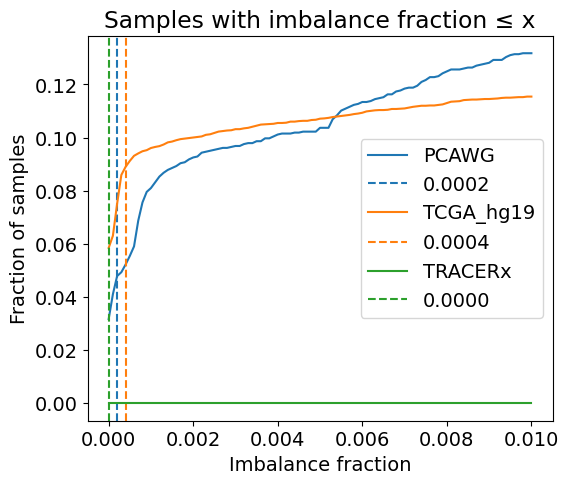

In [182]:
for k, v in sample_count.items():
    plt.plot(sample_cutoffs[k], v, label=k, color=data[k].color)    
    knee_point, knee_value = find_knee(v, convex=True, dist=10)
    print(k, knee_point, knee_value)
    x_pos = sample_cutoffs[k][knee_point]
    plt.axvline(x_pos, color=data[k].color, linestyle="--", label=f"{x_pos:.4f}")
    
plt.xlabel("Imbalance fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with imbalance fraction ≤ x")
plt.savefig(f"{img_path}/fig_samples_imbalance_fraction_full{file_type}", bbox_inches="tight")

In [183]:
cov_count = {}
cov_cutoffs = {}
feature = "cover_frac_aut"
min_val = 0.75
for k, v in data.items():
    cov_cutoffs[k], cov_count[k] = count_below_lim(v.samples[feature], min=min_val, steps=250)

PCAWG 226 0.02816774658027358
TCGA_hg19 200 0.049533846777462504
TRACERx 149 0.02181274900398406


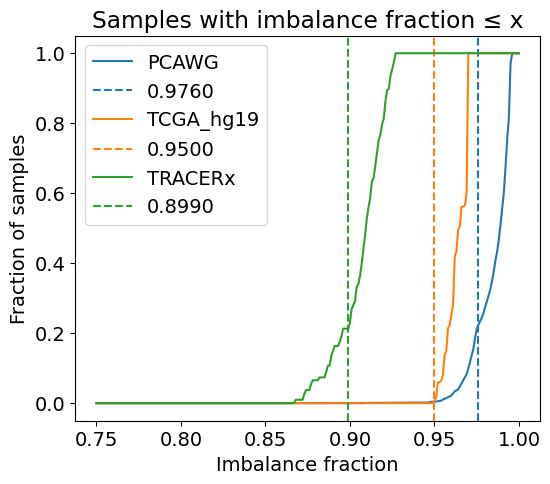

In [185]:
for k, v in cov_count.items():
    plt.plot(cov_cutoffs[k], v, label=k, color=data[k].color)    
    knee_point, knee_value = find_knee(v, convex=False, dist=20)
    print(k, knee_point, knee_value)
    x_pos = cov_cutoffs[k][knee_point]
    plt.axvline(x_pos, color=data[k].color, linestyle="--", label=f"{x_pos:.4f}")
    
plt.xlabel("Imbalance fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with imbalance fraction ≤ x")
plt.savefig(f"{img_path}/fig_samples_coverage_fraction_full{file_type}", bbox_inches="tight")

In [199]:
break_count = {}
break_cutoffs = {}
feature = "breaks_aut"
steps = 100
for k, v in data.items():
    break_cutoffs[k], break_count[k] = count_below_lim(v.samples[feature], max = steps, steps=steps)

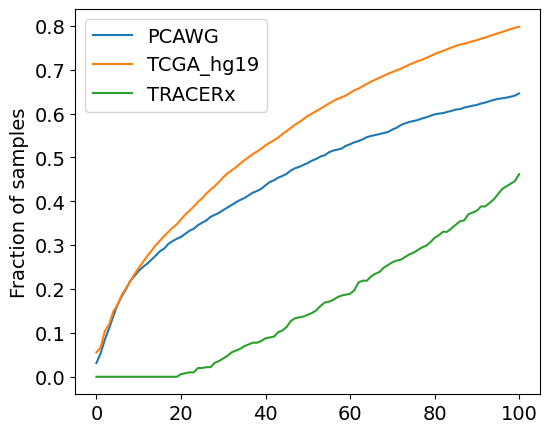

In [201]:
for k, v in break_count.items():
    plt.plot(break_cutoffs[k], v, label=k, color=data[k].color)    
    x_pos = break_cutoffs[k][knee_point]

plt.ylabel("Fraction of samples")
plt.legend()
plt.savefig(f"{img_path}/fig_samples_breaks_fraction_full{file_type}", bbox_inches="tight")

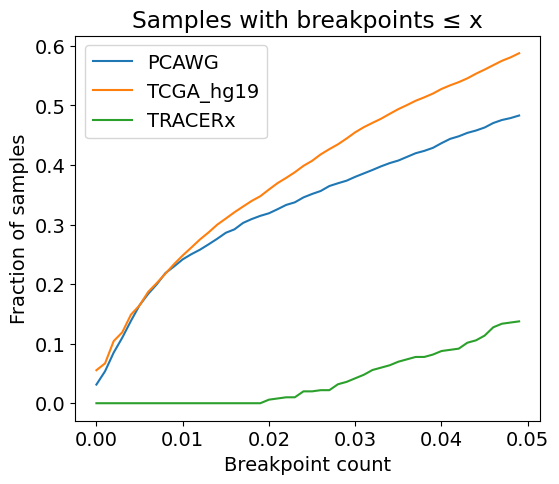

In [202]:
for k, v in break_count.items():
    plt.plot(cutoff[:50], v[:50], label=k)

plt.xlabel("Breakpoint count")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with breakpoints ≤ x")

plt.savefig(f"{img_path}/fig_samples_breaks_fraction{file_type}", bbox_inches="tight")